**STOCK MARKET REACTION TO MACROECONOMIC ANNOUNCEMENT PROJECT**


**INTRODUCTION:**
Macroeconomic announcements play a critical role in shaping financial market expectations. Among them, CPI inflation releases are closely monitored due to their implications for monetary policy.
This project examines whether CPI announcements are associated with increased short-term market volatility, using an event-driven machine learning framework.

**DATA DESCRIPTION: **
- S&P 500 daily price data from Yahoo Finance
- CPI inflation data from FRED (CPIAUCSL)
- Daily frequency from 2015-2025

**FEATURE ENGINEERING:**
Key engineered features include:
- Daily log returns
- Rolling 20-day volatility
- CPI release indicator aligned with trading days
Volatility is chosen as the prediction target due to its stronger relationship with macroeconomic uncertainty.

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
sp500 = yf.download("^GSPC", start = "2015-01-01", end = "2025-01-01", progress = False)
sp500.columns = sp500.columns.droplevel(1)
sp500.columns



/tmp/ipython-input-3702045305.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start = "2015-01-01", end = "2025-01-01", progress = False)


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [ ]:
sp500['return'] = np.log(
    sp500['Close']/sp500['Close'].shift(1)
    )
sp500.dropna(inplace = True)
sp500.reset_index()
sp500.rename(columns = {"Date": "date"}, inplace = True)
sp500.head()


Price,Close,High,Low,Open,Volume,return
Date,,,,,,
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000,-0.018447
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000,-0.008933
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000,0.011563
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000,0.017730
2015-01-09,2044.810059,2064.429932,2038.329956,2063.449951,3364140000,-0.008439


In [ ]:
sp500.to_csv("data_raw_sp500_return.csv", index = False)

In [ ]:
import pandas_datareader.data as web
import datetime as dt

start = dt.datetime(2015, 1,1)
end = dt.datetime(2025, 1, 1)

cpi = web.DataReader("CPIAUCSL", "fred", start, end)
cpi.head()

,CPIAUCSL
DATE,
2015-01-01,234.747
2015-02-01,235.342
2015-03-01,235.976
2015-04-01,236.222
2015-05-01,237.001


In [ ]:
cpi['cpi_release'] = 1
sp500 = sp500.merge(
    cpi[['cpi_release']],
    left_index = True,
    right_index = True,
    how = 'left'
)
sp500['cpi_release'] = sp500['cpi_release'].fillna(0)
sp500


,Close,High,Low,Open,Volume,return,cpi_release
Date,,,,,,,
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000,-0.018447,0.0
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000,-0.008933,0.0
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000,0.011563,0.0
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000,0.017730,0.0
2015-01-09,2044.810059,2064.429932,2038.329956,2063.449951,3364140000,-0.008439,0.0
...,...,...,...,...,...,...,...
2024-12-24,6040.040039,6040.100098,5981.439941,5984.629883,1757720000,0.010982,0.0
2024-12-26,6037.589844,6049.750000,6007.370117,6024.970215,2904530000,-0.000406,0.0
2024-12-27,5970.839844,6006.169922,5932.950195,6006.169922,3159610000,-0.011117,0.0


In [ ]:
sp500.groupby('cpi_release')['return'].mean()

,return
cpi_release,
0.0,0.000388
1.0,0.001313


In [ ]:
sp500['cpi_t'] = sp500['cpi_release']
sp500['cpi_t-1'] = sp500['cpi_release'].shift(1)
sp500['cpi_t+1'] = sp500['cpi_release'].shift(-1)
sp500[['cpi_t', 'cpi_t-1', 'cpi_t+1']] = (sp500[['cpi_t', 'cpi_t-1', 'cpi_t+1']].fillna(0))

In [ ]:
event_days = sp500[
    (sp500['cpi_t']==1) | (sp500['cpi_t-1']==1) | (sp500['cpi_t+1']==1)
]

non_event_days = sp500[
    (sp500['cpi_t']==0) & (sp500['cpi_t-1']==0) & (sp500['cpi_t+1']==0)
]

In [ ]:
event_days['return'].mean(), non_event_days['return'].mean()


(np.float64(0.0005681715402519548), np.float64(0.0004016004193837827))

In [ ]:
event_days['return'].std(),non_event_days['return'].std()

(0.010046350117163313, 0.011393009080440511)

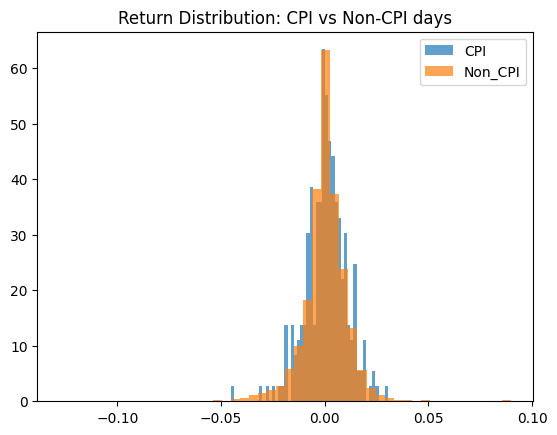

In [ ]:
import matplotlib.pyplot as plt
plt.hist(event_days['return'], bins = 50, alpha = 0.7, label = 'CPI', density = True)
plt.hist(non_event_days['return'], bins = 50, alpha = 0.7, label = 'Non_CPI', density = True)
plt.title('Return Distribution: CPI vs Non-CPI days')
plt.legend(loc = 'upper right')
plt.show()

In [ ]:
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(
    event_days['return'],
    non_event_days['return'],
    equal_var = False
)
t_stat, p_value

(np.float64(0.24102970406123056), np.float64(0.8096926447993366))

**MODELLING APPROACH:**
A logistic regression classifier is trained using a time-series-aware train/test split. Feature scaling and class balancing are applied to improve model stability.

In [ ]:
sp500['volatility'] = sp500['return'].rolling(window = 20).std()
sp500['target'] = (sp500['return'].shift(-1)>0).astype(int)
sp500 = sp500.dropna()
sp500[['return', 'cpi_release', 'volatility', 'target']].head()


,return,cpi_release,volatility,target
Date,,,,
2015-03-27,0.002366,0.0,0.008814,1
2015-03-30,0.012162,0.0,0.009169,0
2015-03-31,-0.008835,0.0,0.009312,0
2015-04-01,-0.003973,1.0,0.009304,1
2015-04-02,0.003523,0.0,0.009347,1


In [ ]:
features = ['cpi_release', 'volatility']
X = sp500[features]
y = sp500['target']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    shuffle = False
)
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.556910569105691
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       218
           1       0.56      1.00      0.72       274

    accuracy                           0.56       492
   macro avg       0.28      0.50      0.36       492
weighted avg       0.31      0.56      0.40       492



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
sp500['vol_spike'] = (
    sp500['volatility'].shift(-1) > sp500['volatility'].rolling(60).mean()
).astype(int)
sp500 = sp500.dropna()
sp500['vol_spike'].value_counts(normalize = True)


,proportion
vol_spike,
0,0.548413
1,0.451587


In [ ]:
fea = ['cpi_release', 'volatility', 'return']
X = sp500[fea]
y = sp500['vol_spike']
X_train, X_test, y_train, y_test = train_test_split (X,y, test_size=0.2, shuffle = False)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(class_weight = 'balanced')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))


Accuracy: 0.6361788617886179
ROC AUC: 0.7584908918242251
              precision    recall  f1-score   support

           0       0.65      0.84      0.74       297
           1       0.57      0.32      0.41       195

    accuracy                           0.64       492
   macro avg       0.61      0.58      0.57       492
weighted avg       0.62      0.64      0.61       492



**RESULTS AND EVALUATION:**
Model performance is evaluated using accuracy, ROC-AUC, and classification metrics. Results indicate a higher likelihood of volatility spike following CPI announcement days.

**LIMITATIONS AND FUTURE WORK:**
The analysis is limited by the absencec of CPI forecast data and daily frequency resolution. Future work could incorporate CPI surprises and intraday volatility measures.